<a href="https://colab.research.google.com/github/Vithya-Sree/taxi-data-analysis-python/blob/main/TAXI_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAXI DATA ANALYSIS USING PANDAS, MATPLOTLIB AND SEABORN

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [2]:
df = sns.load_dataset("taxis")
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [4]:
# Dataset dimensions
print("\nDataset Shape:", df.shape)


Dataset Shape: (6433, 14)


# 2. Handling Missing Values

In [5]:
# Check missing values
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [7]:
# Create a copy of the dataset
df_clean = df.copy()

In [8]:
# Convert pickup and dropoff to datetime
df_clean["pickup"] = pd.to_datetime(df_clean["pickup"],
                                    errors="coerce")
df_clean["dropoff"] = pd.to_datetime(df_clean["dropoff"],
                                     errors="coerce")

In [9]:
# Remove rows where essential timestamps are missing
df_clean = df_clean.dropna(subset=["pickup", "dropoff"])

In [12]:
# Fill numerical columns with median
for col in df_clean.select_dtypes(include="number").columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [14]:
# Fill categorical columns with mode
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [17]:
# Check missing values after cleaning
print(df_clean.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [18]:
print(df.shape)

(6433, 14)


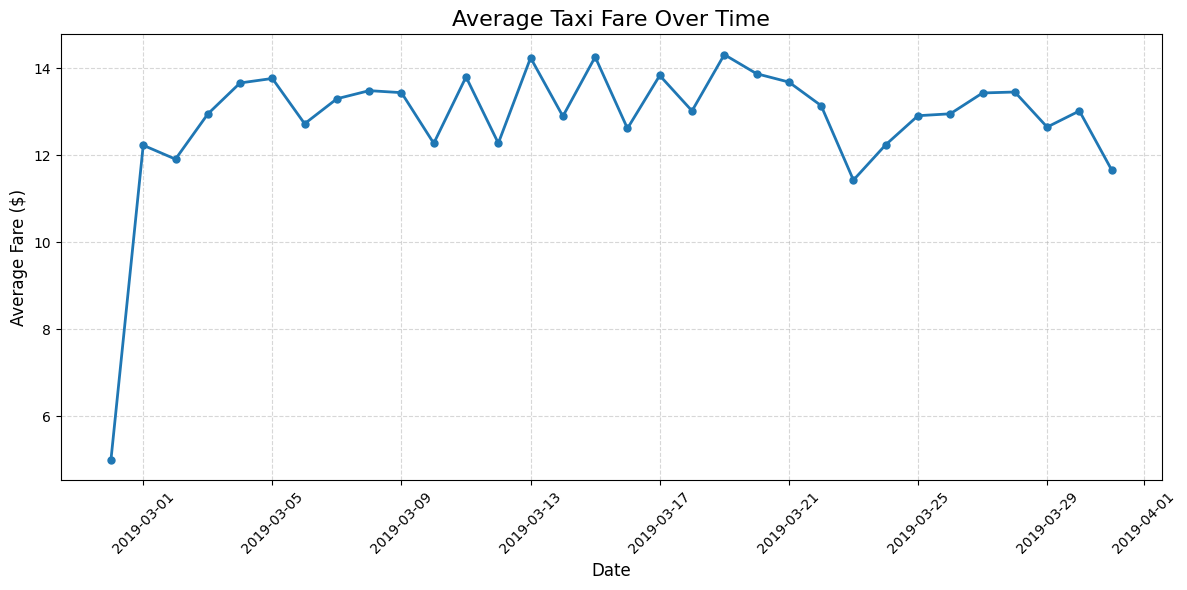

In [36]:
# 4. LINE CHART - Fare Over Time

df_clean["pickup"] = pd.to_datetime(df_clean["pickup"])

# Calculate average fare for each day
daily_fare = df_clean.groupby(
    df_clean["pickup"].dt.date
)["fare"].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    daily_fare.index,
    daily_fare.values,
    marker="o",
    linewidth=2,
    markersize=5
)

plt.title("Average Taxi Fare Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Fare ($)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

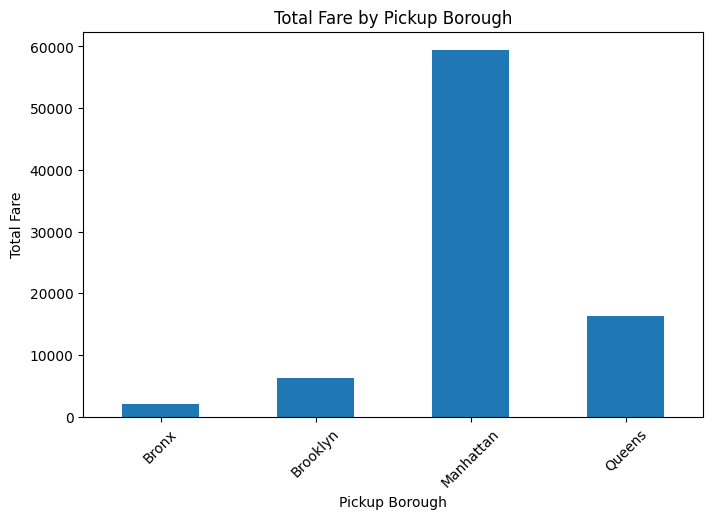

In [23]:
# 5. BAR CHART - Total Fare by Pickup Borough

borough_fare = df_clean.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8, 5))
borough_fare.plot(kind="bar")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

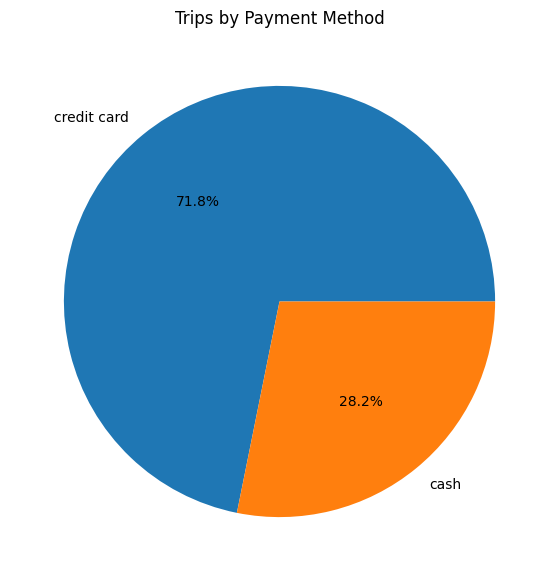

In [24]:
# 6. PIE CHART - Payment Method Distribution

payment_counts = df_clean["payment"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Trips by Payment Method")
plt.show()

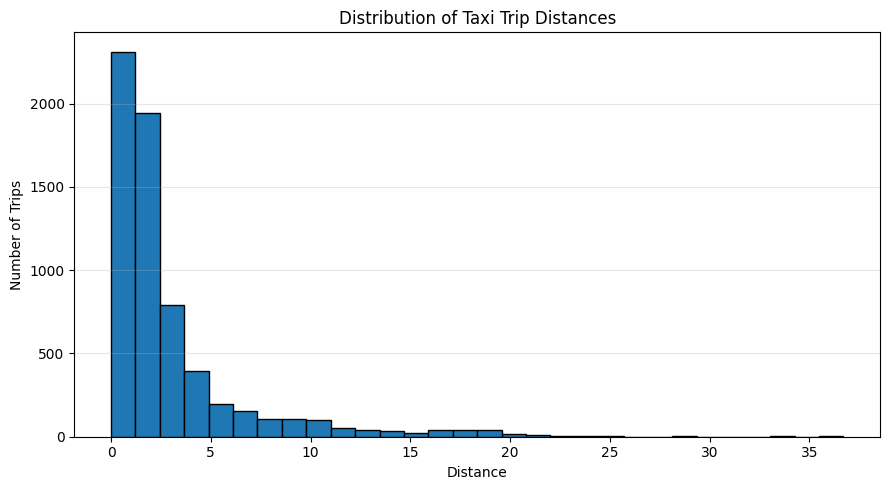

In [26]:
# 7. HISTOGRAM - Distance Distribution

plt.figure(figsize=(9, 5))
plt.hist(df_clean["distance"], bins=30, edgecolor="black")
plt.title("Distribution of Taxi Trip Distances")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

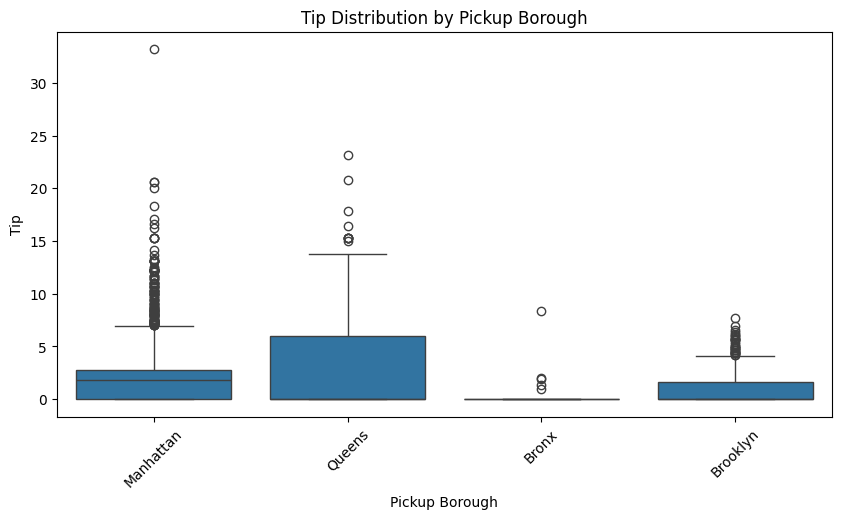

In [27]:
# 8. BOX PLOT - Tips by Pickup Borough

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="pickup_borough",
    y="tip"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.title("Tip Distribution by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

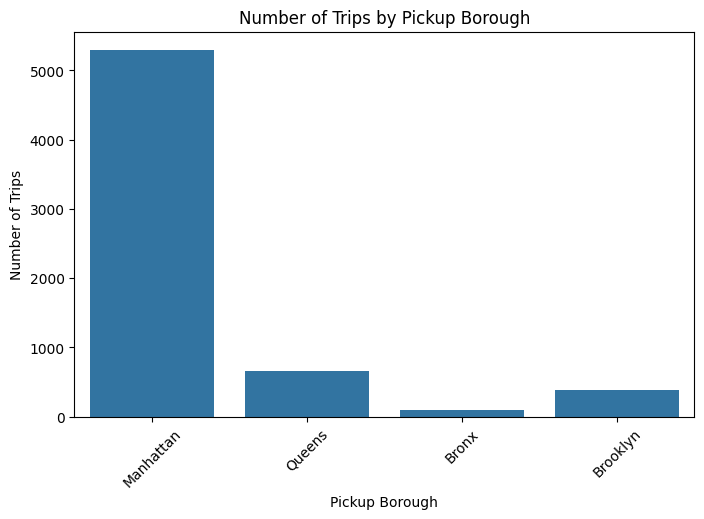

In [28]:
# 9. COUNT PLOT - Trips by Pickup Borough

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="pickup_borough"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

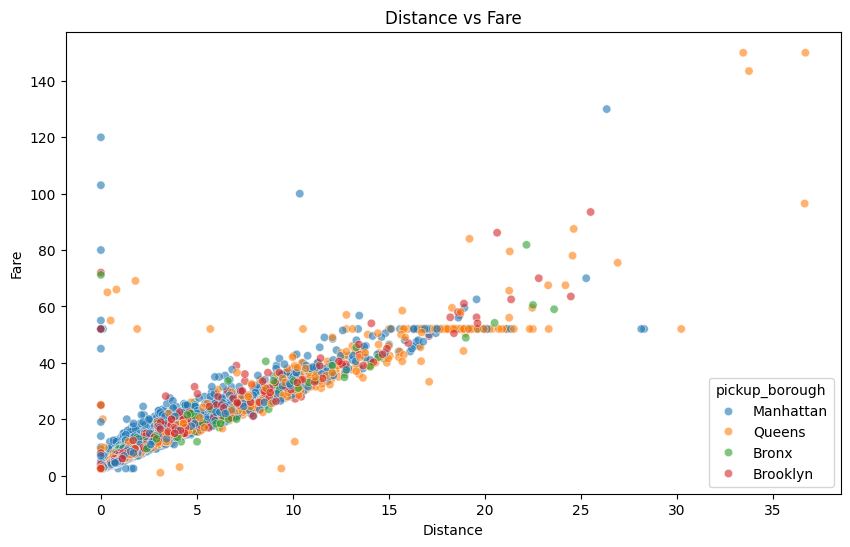

In [29]:
# 10. SCATTER PLOT - Distance vs Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.6
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare")
plt.show()

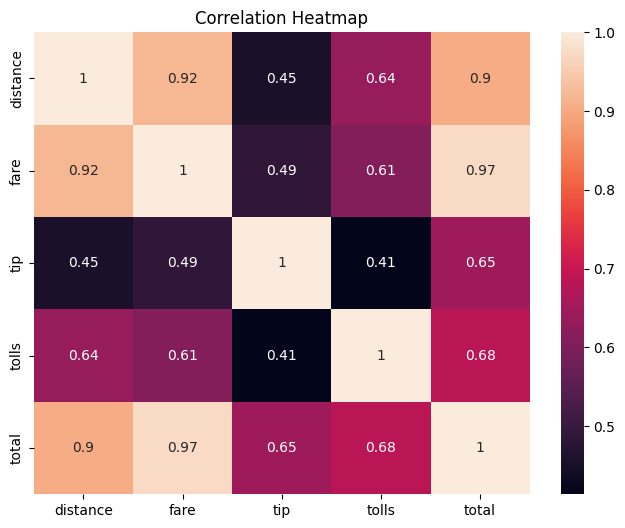

In [30]:
# 11. HEATMAP - Correlation Matrix

columns = ["distance", "fare", "tip", "tolls", "total"]

correlation = df_clean[columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()


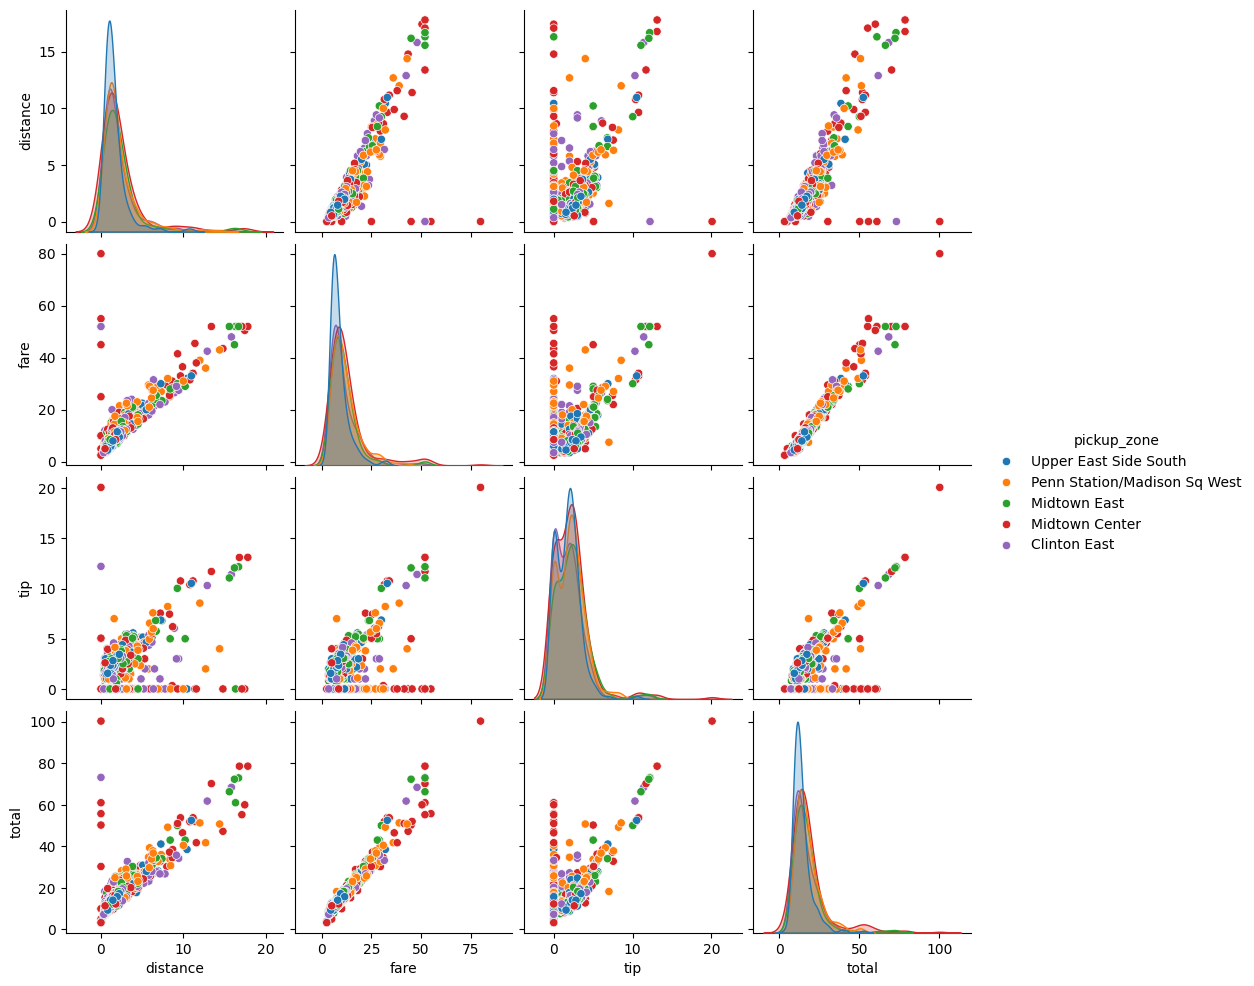

In [34]:
# 12. PAIR PLOT - Pairwise Relationships

top_zones = df_clean["pickup_zone"].value_counts().head(5).index

sample_data = df_clean[
    df_clean["pickup_zone"].isin(top_zones)
].sample(1000, random_state=42)

sns.pairplot(
    sample_data,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

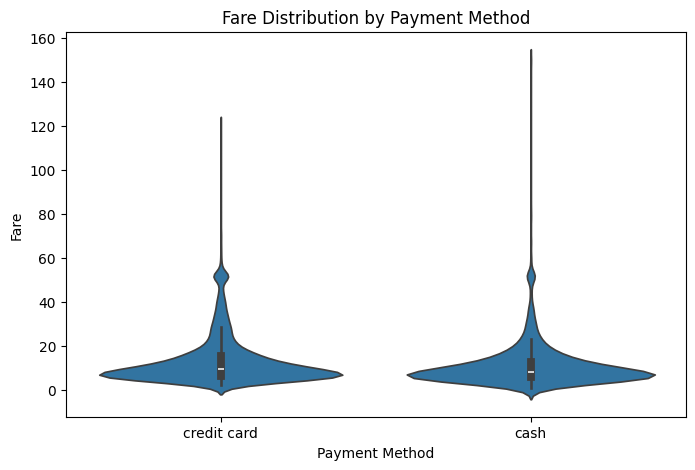

In [35]:
# 13. VIOLIN PLOT - Fare by Payment Method

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_clean,
    x="payment",
    y="fare"
)

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Fare Distribution by Payment Method")
plt.show()